In [ ]:
import xarray as xr
xr.open_dataset("/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc")

In [ ]:
#!/usr/bin/env python3
import os
import glob
import re
import numpy as np
import xarray as xr
from joblib import Parallel, delayed

TXx_FILE = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"
RANDOM_Q_DIR = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/random_q_null"
OUT_DIR = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/random_q_null_correlations"
os.makedirs(OUT_DIR, exist_ok=True)

TX_VAR = "txx"
Q_RANDOM_VAR = "q_random_jja_at_tasmax"

n_jobs = 20

realization_re = re.compile(
    r"q_random_jja_at_tasmax_realization_(\d{4})\.nc$"
)

random_files = sorted(glob.glob(
    os.path.join(RANDOM_Q_DIR, "q_random_jja_at_tasmax_realization_*.nc")
))

print(f"[INFO] Found {len(random_files)} random q realization files")


def realization_number(path):
    m = realization_re.search(os.path.basename(path))
    if not m:
        raise ValueError(f"Could not parse realization number from {path}")
    return int(m.group(1))


def compute_corr_for_realization(random_q_file):
    realization = realization_number(random_q_file)

    out_file = os.path.join(
        OUT_DIR,
        f"corr_txx_random_q_realization_{realization:04d}.nc"
    )

    if os.path.exists(out_file):
        print(f"[SKIP] realization {realization:04d}")
        return out_file

    ds_txx = xr.open_dataset(TXx_FILE)
    ds_q = xr.open_dataset(random_q_file)

    txx = ds_txx[TX_VAR]
    q_random = ds_q[Q_RANDOM_VAR].isel(lev=0)

    # align years/lat/lon safely
    txx, q_random = xr.align(txx, q_random, join="inner")

    r = xr.corr(txx, q_random, dim="year")
    r = r.rename("r_txx_random_q")

    out = xr.Dataset({
        "r_txx_random_q": r.astype("float32")
    })

    out = out.expand_dims(realization=[realization])

    out.attrs.update({
        "description": "Null correlation between TXx and randomized JJA q_at_tasmax",
        "txx_file": TXx_FILE,
        "random_q_file": random_q_file,
        "txx_variable": TX_VAR,
        "q_variable": Q_RANDOM_VAR,
        "correlation_dim": "year",
    })

    encoding = {
        "r_txx_random_q": {"zlib": True, "complevel": 4}
    }

    out.to_netcdf(out_file, encoding=encoding)

    ds_txx.close()
    ds_q.close()
    out.close()

    print(f"[SAVED] realization {realization:04d}")
    return out_file


corr_files = Parallel(n_jobs=n_jobs, backend="loky")(
    delayed(compute_corr_for_realization)(f)
    for f in random_files
)

print(f"[DONE] wrote {len(corr_files)} correlation files to {OUT_DIR}")

In [ ]:
#run in terminal:
#module load nco
#ncecat -O corr_txx_random_q_realization_*.nc corr_txx_random_q_all_realizations.nc

In [ ]:
#!/usr/bin/env python3
import os
import glob
import re
import numpy as np
import xarray as xr
from joblib import Parallel, delayed

TXx_FILE = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"
RANDOM_Q_DIR = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/random_q_null"

TX_VAR = "txx"
Q_RANDOM_VAR = "q_random_jja_at_tasmax"

CONTROL_VAR = "t500_premax_3d"
MIN_N = 20
n_jobs = 20

OUT_DIR = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/random_q_null_partial_correlations"
os.makedirs(OUT_DIR, exist_ok=True)


realization_re = re.compile(
    r"q_random_jja_at_tasmax_realization_(\d{4})\.nc$"
)

random_files = sorted(glob.glob(
    os.path.join(RANDOM_Q_DIR, "q_random_jja_at_tasmax_realization_*.nc")
))

print(f"[INFO] Found {len(random_files)} random q realization files")


def realization_number(path):
    m = realization_re.search(os.path.basename(path))
    if not m:
        raise ValueError(f"Could not parse realization number from {path}")
    return int(m.group(1))


def partial_corr_xr(x, y, z, dim="year", min_n=20):
    x, y, z = xr.align(x, y, z, join="inner")

    valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)
    nvalid = valid.sum(dim)

    x = x.where(valid).where(nvalid >= min_n)
    y = y.where(valid).where(nvalid >= min_n)
    z = z.where(valid).where(nvalid >= min_n)

    r_xy = xr.corr(x, y, dim=dim)
    r_xz = xr.corr(x, z, dim=dim)
    r_yz = xr.corr(y, z, dim=dim)

    r_partial = (
        (r_xy - r_xz * r_yz)
        / np.sqrt((1 - r_xz**2) * (1 - r_yz**2))
    )

    return r_partial.where(np.isfinite(r_partial))


def compute_corr_for_realization(random_q_file):
    realization = realization_number(random_q_file)

    out_file = os.path.join(
        OUT_DIR,
        f"partial_corr_txx_random_q_control_t500_realization_{realization:04d}.nc"
    )

    if os.path.exists(out_file):
        print(f"[SKIP] realization {realization:04d}")
        return out_file

    ds_txx = xr.open_dataset(TXx_FILE)
    ds_q = xr.open_dataset(random_q_file)

    txx = ds_txx[TX_VAR]
    t500 = ds_txx[CONTROL_VAR]

    q_random = ds_q[Q_RANDOM_VAR]

    # If q has a lev dimension, select first level
    if "lev" in q_random.dims:
        q_random = q_random.isel(lev=0)

    r = partial_corr_xr(
        txx,
        q_random,
        t500,
        dim="year",
        min_n=MIN_N
    )

    r = r.rename("r_partial_txx_random_q_control_t500")

    out = xr.Dataset({
        "r_partial_txx_random_q_control_t500": r.astype("float32")
    })

    out = out.expand_dims(realization=[realization])

    out.attrs.update({
        "description": "Null partial correlation between TXx and randomized JJA q_at_tasmax, controlling for T500",
        "txx_file": TXx_FILE,
        "random_q_file": random_q_file,
        "txx_variable": TX_VAR,
        "q_variable": Q_RANDOM_VAR,
        "control_variable": CONTROL_VAR,
        "correlation_dim": "year",
        "min_valid_years": MIN_N,
    })

    encoding = {
        "r_partial_txx_random_q_control_t500": {
            "zlib": True,
            "complevel": 4
        }
    }

    out.to_netcdf(out_file, encoding=encoding)

    ds_txx.close()
    ds_q.close()
    out.close()

    print(f"[SAVED] realization {realization:04d}")
    return out_file


corr_files = Parallel(n_jobs=n_jobs, backend="loky")(
    delayed(compute_corr_for_realization)(f)
    for f in random_files
)

print(f"[DONE] wrote {len(corr_files)} correlation files to {OUT_DIR}")

In [17]:
#!/usr/bin/env python3
import os
import glob
import re
import numpy as np
import xarray as xr
from joblib import Parallel, delayed

TXx_FILE = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"
RANDOM_Q_DIR = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/random_q_null"

TX_VAR = "txx"
Q_RANDOM_VAR = "q_random_jja_at_tasmax"

CONTROL_VAR = "mse_sat"
MIN_N = 20
n_jobs = 20

OUT_DIR = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/random_q_null_partial_correlations_mse"
os.makedirs(OUT_DIR, exist_ok=True)


realization_re = re.compile(
    r"q_random_jja_at_tasmax_realization_(\d{4})\.nc$"
)

random_files = sorted(glob.glob(
    os.path.join(RANDOM_Q_DIR, "q_random_jja_at_tasmax_realization_*.nc")
))

print(f"[INFO] Found {len(random_files)} random q realization files")


def realization_number(path):
    m = realization_re.search(os.path.basename(path))
    if not m:
        raise ValueError(f"Could not parse realization number from {path}")
    return int(m.group(1))


def partial_corr_xr(x, y, z, dim="year", min_n=20):
    x, y, z = xr.align(x, y, z, join="inner")

    valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)
    nvalid = valid.sum(dim)

    x = x.where(valid).where(nvalid >= min_n)
    y = y.where(valid).where(nvalid >= min_n)
    z = z.where(valid).where(nvalid >= min_n)

    r_xy = xr.corr(x, y, dim=dim)
    r_xz = xr.corr(x, z, dim=dim)
    r_yz = xr.corr(y, z, dim=dim)

    r_partial = (
        (r_xy - r_xz * r_yz)
        / np.sqrt((1 - r_xz**2) * (1 - r_yz**2))
    )

    return r_partial.where(np.isfinite(r_partial))


def compute_corr_for_realization(random_q_file):
    realization = realization_number(random_q_file)

    out_file = os.path.join(
        OUT_DIR,
        f"partial_corr_txx_random_q_control_mse_sat_realization_{realization:04d}.nc"
    )

    if os.path.exists(out_file):
        print(f"[SKIP] realization {realization:04d}")
        return out_file

    ds_txx = xr.open_dataset(TXx_FILE)
    ds_q = xr.open_dataset(random_q_file)

    txx = ds_txx[TX_VAR]
    t500 = ds_txx[CONTROL_VAR]

    q_random = ds_q[Q_RANDOM_VAR]

    # If q has a lev dimension, select first level
    if "lev" in q_random.dims:
        q_random = q_random.isel(lev=0)

    r = partial_corr_xr(
        txx,
        q_random,
        t500,
        dim="year",
        min_n=MIN_N
    )

    r = r.rename("r_partial_txx_random_q_control_mse_sat")

    out = xr.Dataset({
        "r_partial_txx_random_q_control_mse_sat": r.astype("float32")
    })

    out = out.expand_dims(realization=[realization])

    out.attrs.update({
        "description": "Null partial correlation between TXx and randomized JJA q_at_tasmax, controlling for mse_sat",
        "txx_file": TXx_FILE,
        "random_q_file": random_q_file,
        "txx_variable": TX_VAR,
        "q_variable": Q_RANDOM_VAR,
        "control_variable": CONTROL_VAR,
        "correlation_dim": "year",
        "min_valid_years": MIN_N,
    })

    encoding = {
        "r_partial_txx_random_q_control_mse_sat": {
            "zlib": True,
            "complevel": 4
        }
    }

    out.to_netcdf(out_file, encoding=encoding)

    ds_txx.close()
    ds_q.close()
    out.close()

    print(f"[SAVED] realization {realization:04d}")
    return out_file


corr_files = Parallel(n_jobs=n_jobs, backend="loky")(
    delayed(compute_corr_for_realization)(f)
    for f in random_files
)

print(f"[DONE] wrote {len(corr_files)} correlation files to {OUT_DIR}")

[INFO] Found 1000 random q realization files
[DONE] wrote 1000 correlation files to /work/uc1275/u301827/02_MSE/full_midlatitude/TXX/random_q_null_partial_correlations_mse


In [10]:
#!/usr/bin/env python3
import os
import glob
import re
import numpy as np
import xarray as xr
from joblib import Parallel, delayed

TXx_FILE = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"
RANDOM_Q_DIR = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/random_t_null"
OUT_DIR = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/random_t_null_correlations"
os.makedirs(OUT_DIR, exist_ok=True)

TX_VAR = "txx"
Q_RANDOM_VAR = "t_random_jja_dailymax"

n_jobs = 20

realization_re = re.compile(
    r"q_random_jja_at_tasmax_realization_(\d{4})\.nc$"
)

random_files = sorted(glob.glob(
    os.path.join(RANDOM_Q_DIR, "q_random_jja_at_tasmax_realization_*.nc")
))

print(f"[INFO] Found {len(random_files)} random q realization files")


def realization_number(path):
    m = realization_re.search(os.path.basename(path))
    if not m:
        raise ValueError(f"Could not parse realization number from {path}")
    return int(m.group(1))


def compute_corr_for_realization(random_q_file):
    realization = realization_number(random_q_file)

    out_file = os.path.join(
        OUT_DIR,
        f"corr_txx_random_q_realization_{realization:04d}.nc"
    )

    if os.path.exists(out_file):
        print(f"[SKIP] realization {realization:04d}")
        return out_file

    ds_txx = xr.open_dataset(TXx_FILE)
    ds_q = xr.open_dataset(random_q_file)

    txx = ds_txx[TX_VAR]
    q_random = ds_q[Q_RANDOM_VAR]

    # align years/lat/lon safely
    txx, q_random = xr.align(txx, q_random, join="inner")

    r = xr.corr(txx, q_random, dim="year")
    r = r.rename("r_txx_random_t")

    out = xr.Dataset({
        "r_txx_random_t": r.astype("float32")
    })

    out = out.expand_dims(realization=[realization])

    out.attrs.update({
        "description": "Null correlation between TXx and randomized JJA t_at_dailymax",
        "txx_file": TXx_FILE,
        "random_q_file": random_q_file,
        "txx_variable": TX_VAR,
        "t_variable": Q_RANDOM_VAR,
        "correlation_dim": "year",
    })

    encoding = {
        "r_txx_random_t": {"zlib": True, "complevel": 4}
    }

    out.to_netcdf(out_file, encoding=encoding)

    ds_txx.close()
    ds_q.close()
    out.close()

    print(f"[SAVED] realization {realization:04d}")
    return out_file


corr_files = Parallel(n_jobs=n_jobs, backend="loky")(
    delayed(compute_corr_for_realization)(f)
    for f in random_files
)

print(f"[DONE] wrote {len(corr_files)} correlation files to {OUT_DIR}")

[INFO] Found 1000 random q realization files
[DONE] wrote 1000 correlation files to /work/uc1275/u301827/02_MSE/full_midlatitude/TXX/random_t_null_correlations


In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import regionmask

# -----------------------
# Paths
# -----------------------
path_txx = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"

# -----------------------
# Load dataset
# -----------------------
ds = xr.open_dataset(path_txx)

# -----------------------
# Latitude band only
# -----------------------
lat_min, lat_max = 40.0, 65.0

def sel_lat_band(ds_in, lat_min, lat_max, lat_name="lat"):
    lat = ds_in[lat_name]
    if lat[0] > lat[-1]:  # descending
        return ds_in.sel({lat_name: slice(lat_max, lat_min)})
    else:
        return ds_in.sel({lat_name: slice(lat_min, lat_max)})

ds_band = sel_lat_band(ds, lat_min, lat_max).sortby("lon")

# -----------------------
# Variables
# -----------------------
txx  = ds_band["txx"]
t500 = ds_band["q_at_tasmax"]

txx, t500 = xr.align(txx, t500, join="inner")

# -----------------------
# Require at least N valid years per grid cell
# -----------------------
min_n = 20
nvalid = (np.isfinite(txx) & np.isfinite(t500)).sum("year")

txx  = txx.where(nvalid >= min_n)
t500 = t500.where(nvalid >= min_n)

# -----------------------
# Correlation per grid cell
# -----------------------
r = xr.corr(txx, t500, dim="year")

# -----------------------
# Land-only mask (optional)
# -----------------------
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
land_mask = (land.mask(ds_band["lon"], ds_band["lat"]) == 0)
r_land = r.where(land_mask)

# -----------------------
# Load null correlations
# -----------------------
path_null = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/random_q_null_correlations/corr_txx_random_q_all_realizations.nc"

ds_null = xr.open_dataset(path_null)

# If variable has both record and realization dimensions,
# remove the old realization dimension of length 1
if "realization" in ds_null.dims and ds_null.dims["realization"] == 1:
    ds_null = ds_null.isel(realization=0, drop=True)

# Now rename record -> realization
ds_null = ds_null.rename({"record": "realization"})

# Add clean realization coordinate
ds_null = ds_null.assign_coords(
    realization=np.arange(ds_null.dims["realization"])
)

r_null = ds_null["r_txx_random_q"]

# Match lat/lon band and ordering
r_null_band = sel_lat_band(r_null, lat_min, lat_max).sortby("lon")

# Align observed and null fields
r_obs, r_null_band = xr.align(r_land, r_null_band, join="inner")

# -----------------------
# Empirical significance for negative correlations
# -----------------------
# One-sided p-value:
# fraction of null correlations <= observed correlation
p_neg = (r_null_band <= r_obs).mean("realization")

# Significance level = 1 - p
sig_neg = 1 - p_neg

# Only show where observed correlation is negative
sig_neg_land = sig_neg.where(r_obs < 0)

In [ ]:
# -----------------------
# Plot negative-correlation significance map
# -----------------------
proj = ccrs.PlateCarree(central_longitude=135)
data_crs = ccrs.PlateCarree()

fig = plt.figure(figsize=(16, 4))
ax = plt.axes(projection=proj)

ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, alpha=0.10)

lonL, lonR = -15, 310
ax.set_extent([lonL, lonR, lat_min, lat_max], crs=data_crs)

im = sig_neg_land.plot(
    ax=ax,
    transform=data_crs,
    x="lon",
    y="lat",
    cmap="viridis",
    vmin=0.90,
    vmax=1.001,
    levels=np.linspace(0.90, 1.001, 11),
    add_colorbar=False,
)

ax.set_title("Significance level of negative correlations: TXx vs Near Surface Moisture")

cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    pad=0.025,
    fraction=0.06,
    aspect=66,
)

cbar.set_label("Empirical significance level, 1 - p", fontsize=12)
cbar.ax.tick_params(labelsize=11)

plt.savefig(
    "q_at_tasmax_vs_TXX_negative_correlation_significance_map.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import regionmask

# -----------------------
# Paths
# -----------------------
path_txx = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"

# -----------------------
# Load dataset
# -----------------------
ds = xr.open_dataset(path_txx)

# -----------------------
# Latitude band only
# -----------------------
lat_min, lat_max = 40.0, 65.0

def sel_lat_band(ds_in, lat_min, lat_max, lat_name="lat"):
    lat = ds_in[lat_name]
    if lat[0] > lat[-1]:  # descending
        return ds_in.sel({lat_name: slice(lat_max, lat_min)})
    else:
        return ds_in.sel({lat_name: slice(lat_min, lat_max)})

ds_band = sel_lat_band(ds, lat_min, lat_max).sortby("lon")

# -----------------------
# Variables
# -----------------------
txx  = ds_band["txx"]
t500 = ds_band["q_at_tasmax"]

txx, t500 = xr.align(txx, t500, join="inner")

# -----------------------
# Require at least N valid years per grid cell
# -----------------------
min_n = 20
nvalid = (np.isfinite(txx) & np.isfinite(t500)).sum("year")

txx  = txx.where(nvalid >= min_n)
t500 = t500.where(nvalid >= min_n)

# -----------------------
# Correlation per grid cell
# -----------------------
r = xr.corr(txx, t500, dim="year")

# -----------------------
# Load null correlations and compute significance
# -----------------------
path_null = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/random_q_null_correlations/corr_txx_random_q_all_realizations.nc"

ds_null = xr.open_dataset(path_null)

# ncecat output likely has record + old realization=1
if "realization" in ds_null.dims and ds_null.dims["realization"] == 1:
    ds_null = ds_null.isel(realization=0, drop=True)

if "record" in ds_null.dims:
    ds_null = ds_null.rename({"record": "realization"})

ds_null = ds_null.assign_coords(
    realization=np.arange(ds_null.dims["realization"])
)

r_null = ds_null["r_txx_random_q"]

r_null_band = sel_lat_band(r_null, lat_min, lat_max).sortby("lon")

r_obs, r_null_band = xr.align(r_land, r_null_band, join="inner")

# one-sided negative significance
p_neg = (r_null_band <= r_obs).mean("realization")
sig_neg = 1 - p_neg

sig_mask = (sig_neg > 0.95) & (r_obs < 0)

# -----------------------
# Land-only mask (optional)
# -----------------------
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
land_mask = (land.mask(ds_band["lon"], ds_band["lat"]) == 0)
r_land = r.where(land_mask)

# -----------------------
# Plot correlation map (horizontal colorbar below)
# -----------------------
proj = ccrs.PlateCarree(central_longitude=135)
data_crs = ccrs.PlateCarree()

fig = plt.figure(figsize=(16, 4))
ax = plt.axes(projection=proj)

ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, alpha=0.10)

lonL, lonR = -15, 310
ax.set_extent([lonL, lonR, lat_min, lat_max], crs=data_crs)

# Plot WITHOUT automatic colorbar
im = r_land.plot(
    ax=ax,
    transform=data_crs,
    x="lon",
    y="lat",
    cmap="RdBu_r",
    vmin=-1, vmax=1, levels = 13,
    add_colorbar=False
)

# -----------------------
# Add coarse, big black dots for significance > 0.9
# -----------------------

# subsample (adjust step to control density)
step = 5

sig_coarse = sig_mask.isel(
    lat=slice(None, None, step),
    lon=slice(None, None, step)
)

yy, xx = xr.broadcast(sig_coarse["lat"], sig_coarse["lon"])

ax.scatter(
    xx.where(sig_coarse).values,
    yy.where(sig_coarse).values,
    s=2,              # BIG points
    c="black",
    marker="o",
    transform=data_crs,
    linewidths=0,
    zorder=5
)

ax.set_title("Grid-cell correlation: TXx vs Near Surface Moisture at Time of TXx")

# Horizontal colorbar below
cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    pad=0.025,
    fraction=0.06,
    aspect=66
)

cbar.set_label(" ", fontsize=12)
cbar.ax.tick_params(labelsize=11)

plt.savefig("q_at_tasmax_vs_TXX_correlation_map.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
r_null_p90 = r_null_band.quantile(0.01, dim="realization")

proj = ccrs.PlateCarree(central_longitude=135)
data_crs = ccrs.PlateCarree()

fig = plt.figure(figsize=(16, 4))
ax = plt.axes(projection=proj)

ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, alpha=0.10)

lonL, lonR = -15, 310
ax.set_extent([lonL, lonR, lat_min, lat_max], crs=data_crs)

im = r_null_p90.plot(
    ax=ax,
    transform=data_crs,
    x="lon",
    y="lat",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    levels=13,
    add_colorbar=False,
)

ax.set_title("90th percentile of null correlation (r)")

cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    pad=0.025,
    fraction=0.06,
    aspect=66,
)

cbar.set_label("r (90th percentile of null)", fontsize=12)
cbar.ax.tick_params(labelsize=11)

plt.savefig(
    "null_correlation_90th_percentile_map.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

done with partials


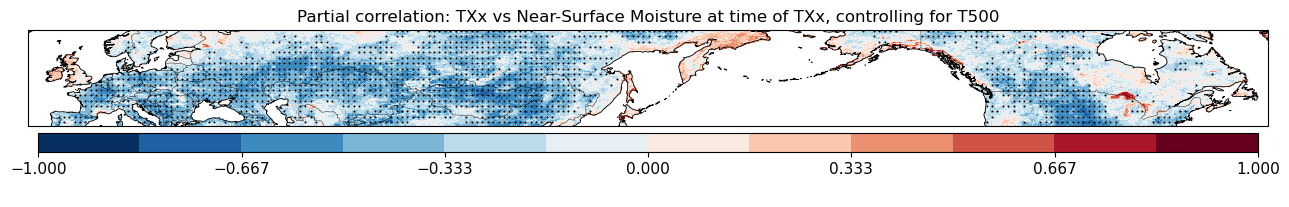

In [6]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import regionmask

# -----------------------
# Paths
# -----------------------
path_txx = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"

path_null = (
    "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/"
    "random_q_null_partial_correlations/"
    "partial_corr_txx_random_q_all_realizations.nc"
)

# -----------------------
# Load dataset
# -----------------------
ds = xr.open_dataset(path_txx)

# -----------------------
# Latitude band only
# -----------------------
lat_min, lat_max = 40.0, 65.0

def sel_lat_band(ds_in, lat_min, lat_max, lat_name="lat"):
    lat = ds_in[lat_name]
    if lat[0] > lat[-1]:  # descending
        return ds_in.sel({lat_name: slice(lat_max, lat_min)})
    else:
        return ds_in.sel({lat_name: slice(lat_min, lat_max)})

ds_band = sel_lat_band(ds, lat_min, lat_max).sortby("lon")

# -----------------------
# Variables
# -----------------------
txx  = ds_band["txx"]
q    = ds_band["q_at_tasmax"]
t500 = ds_band["t500_premax_3d"]

txx, q, t500 = xr.align(txx, q, t500, join="inner")

# -----------------------
# Require at least N valid years per grid cell
# -----------------------
min_n = 20

valid = np.isfinite(txx) & np.isfinite(q) & np.isfinite(t500)
nvalid = valid.sum("year")

txx  = txx.where(valid).where(nvalid >= min_n)
q    = q.where(valid).where(nvalid >= min_n)
t500 = t500.where(valid).where(nvalid >= min_n)

# -----------------------
# Observed partial correlation
# TXx vs q_at_tasmax, controlling for t500_premax_3d
# -----------------------
r_txx_q    = xr.corr(txx, q, dim="year")
r_txx_t500 = xr.corr(txx, t500, dim="year")
r_q_t500   = xr.corr(q, t500, dim="year")

r = (
    (r_txx_q - r_txx_t500 * r_q_t500)
    / np.sqrt((1 - r_txx_t500**2) * (1 - r_q_t500**2))
)

r = r.where(np.isfinite(r))
print("done with partials")
# -----------------------
# Land-only mask
# -----------------------
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110

# important for lon = 0...360 grids
land_mask = land.mask(
    ds_band["lon"],
    ds_band["lat"],
    wrap_lon=True
) == 0

r_land = r.where(land_mask)

# -----------------------
# Load null partial correlations
# -----------------------
ds_null = xr.open_dataset(path_null)

# Handle ncecat-style output
if "realization" in ds_null.dims and ds_null.sizes["realization"] == 1:
    ds_null = ds_null.isel(realization=0, drop=True)

if "record" in ds_null.dims:
    ds_null = ds_null.rename({"record": "realization"})

ds_null = ds_null.assign_coords(
    realization=np.arange(ds_null.sizes["realization"])
)

# Adjust this name if needed
r_null = ds_null["r_partial_txx_random_q_control_t500"]

r_null_band = sel_lat_band(r_null, lat_min, lat_max).sortby("lon")

# Align observed and null
r_obs, r_null_band = xr.align(r_land, r_null_band, join="inner")

# -----------------------
# Significance
# -----------------------
land_mask_obs, p_value, r_obs = xr.align(
    land_mask,
    p_value,
    r_obs,
    join="inner"
)

sig_mask = (
    (p_value < 0.05)
    & (r_obs < 0)
    & land_mask_obs
    & np.isfinite(r_obs)
)

sig_mask = sig_mask.fillna(False)

# -----------------------
# Plot partial correlation map
# -----------------------
proj = ccrs.PlateCarree(central_longitude=135)
data_crs = ccrs.PlateCarree()

fig = plt.figure(figsize=(16, 4))
ax = plt.axes(projection=proj)

ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, alpha=0.10)

lonL, lonR = -15, 310
ax.set_extent([lonL, lonR, lat_min, lat_max], crs=data_crs)

im = r_obs.plot(
    ax=ax,
    transform=data_crs,
    x="lon",
    y="lat",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    levels=13,
    add_colorbar=False
)

# -----------------------
# Add stippling for significant grid cells
# -----------------------
step = 5

sig_coarse = sig_mask.isel(
    lat=slice(None, None, step),
    lon=slice(None, None, step)
)

yy, xx = xr.broadcast(sig_coarse["lat"], sig_coarse["lon"])

ax.scatter(
    xx.where(sig_coarse).values,
    yy.where(sig_coarse).values,
    s=2,
    c="black",
    marker="o",
    transform=data_crs,
    linewidths=0,
    zorder=5
)

ax.set_title(
    "Partial correlation: TXx vs Near-Surface Moisture at time of TXx, controlling for T500"
)

cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    pad=0.025,
    fraction=0.06,
    aspect=66
)

cbar.set_label(" ", fontsize=12)
cbar.ax.tick_params(labelsize=11)

plt.savefig(
    "q_at_tasmax_vs_TXX_partial_correlation_control_T500_significance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

ds.close()
ds_null.close()

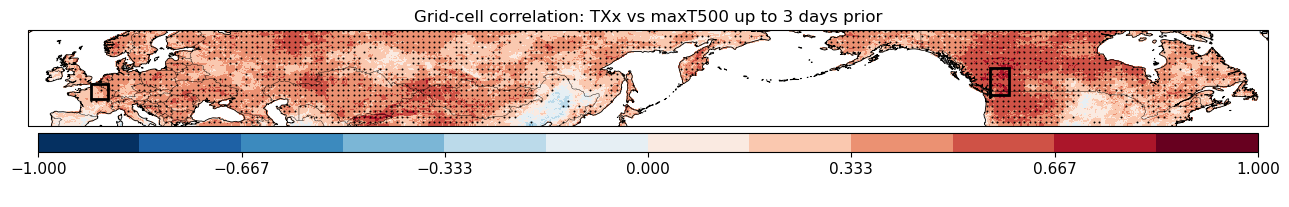

In [15]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import regionmask

# -----------------------
# Paths
# -----------------------
path_txx = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"

path_null = (
    "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/"
    "random_t_null_correlations/corr_txx_random_t_all_realizations.nc"
)

# -----------------------
# Load dataset
# -----------------------
ds = xr.open_dataset(path_txx)

lat_min, lat_max = 40.0, 65.0

def sel_lat_band(ds_in, lat_min, lat_max, lat_name="lat"):
    lat = ds_in[lat_name]
    if lat[0] > lat[-1]:
        return ds_in.sel({lat_name: slice(lat_max, lat_min)})
    else:
        return ds_in.sel({lat_name: slice(lat_min, lat_max)})

ds_band = sel_lat_band(ds, lat_min, lat_max).sortby("lon")

# -----------------------
# Variables
# -----------------------
txx  = ds_band["txx"]
t500 = ds_band["t500_premax_3d"]

txx, t500 = xr.align(txx, t500, join="inner")

# -----------------------
# Require at least N valid years per grid cell
# -----------------------
min_n = 20
valid = np.isfinite(txx) & np.isfinite(t500)
nvalid = valid.sum("year")

txx  = txx.where(valid).where(nvalid >= min_n)
t500 = t500.where(valid).where(nvalid >= min_n)

# -----------------------
# Observed correlation
# -----------------------
r = xr.corr(txx, t500, dim="year")
r = r.where(np.isfinite(r))

# -----------------------
# Land-only mask
# -----------------------
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110

land_mask = land.mask(
    ds_band["lon"],
    ds_band["lat"],
    wrap_lon=True
) == 0

r_land = r.where(land_mask)

# -----------------------
# Load null correlations
# -----------------------
ds_null = xr.open_dataset(path_null)

# Handle ncecat-style output
if "realization" in ds_null.dims and ds_null.sizes["realization"] == 1:
    ds_null = ds_null.isel(realization=0, drop=True)

if "record" in ds_null.dims:
    ds_null = ds_null.rename({"record": "realization"})

ds_null = ds_null.assign_coords(
    realization=np.arange(ds_null.sizes["realization"])
)

# Change this variable name if needed after checking ds_null
r_null = ds_null["r_txx_random_t"]

r_null_band = sel_lat_band(r_null, lat_min, lat_max).sortby("lon")

# Align observed and null
r_obs, r_null_band = xr.align(r_land, r_null_band, join="inner")

# -----------------------
# Significance
# -----------------------
p_value = (
    (np.abs(r_null_band) >= np.abs(r_obs)).sum("realization") + 1
) / (r_null_band.sizes["realization"] + 1)

land_mask_obs, p_value, r_obs = xr.align(
    land_mask,
    p_value,
    r_obs,
    join="inner"
)

sig_mask = (
    (p_value < 0.05)
    & land_mask_obs
    & np.isfinite(r_obs)
)

sig_mask = sig_mask.fillna(False)

# Optional one-sided positive only:
# sig_mask = ((p_value < 0.05) & (r_obs > 0) & land_mask_obs & np.isfinite(r_obs)).fillna(False)

# -----------------------
# Plot correlation map
# -----------------------
proj = ccrs.PlateCarree(central_longitude=135)
data_crs = ccrs.PlateCarree()

fig = plt.figure(figsize=(16, 4))
ax = plt.axes(projection=proj)

ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, alpha=0.10)

lonL, lonR = -15, 310
ax.set_extent([lonL, lonR, lat_min, lat_max], crs=data_crs)

im = r_obs.plot(
    ax=ax,
    transform=data_crs,
    x="lon",
    y="lat",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    levels=13,
    add_colorbar=False
)

# -----------------------
# Add stippling for significant land grid cells
# -----------------------
step = 5

sig_coarse = sig_mask.isel(
    lat=slice(None, None, step),
    lon=slice(None, None, step)
).fillna(False)

sig_points = sig_coarse.stack(points=("lat", "lon"))
sig_points = sig_points.where(sig_points, drop=True)

ax.scatter(
    sig_points["lon"].values,
    sig_points["lat"].values,
    s=2,
    c="black",
    marker="o",
    transform=data_crs,
    linewidths=0,
    zorder=5
)

ax.set_title("Grid-cell correlation: TXx vs maxT500 up to 3 days prior")

# -----------------------
# Define boxes
# -----------------------
lon0_1, lon1_1 = 1.5, 6
lat0_1, lat1_1 = 47.0, 51.0

lon0_2, lon1_2 = 360 - 123, 360 - 118
lat0_2, lat1_2 = 48, 55

rect1 = mpatches.Rectangle(
    (lon0_1, lat0_1),
    lon1_1 - lon0_1,
    lat1_1 - lat0_1,
    linewidth=2,
    edgecolor="black",
    facecolor="none",
    transform=data_crs,
    zorder=6
)

rect2 = mpatches.Rectangle(
    (lon0_2, lat0_2),
    lon1_2 - lon0_2,
    lat1_2 - lat0_2,
    linewidth=2,
    edgecolor="black",
    facecolor="none",
    transform=data_crs,
    zorder=6
)

ax.add_patch(rect1)
ax.add_patch(rect2)

# -----------------------
# Colorbar
# -----------------------
cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    pad=0.025,
    fraction=0.06,
    aspect=66
)

cbar.set_label(" ", fontsize=12)
cbar.ax.tick_params(labelsize=11)

plt.savefig(
    "t500premax_at_tasmax_vs_TXX_correlation_map_significance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

ds.close()
ds_null.close()

done with partials


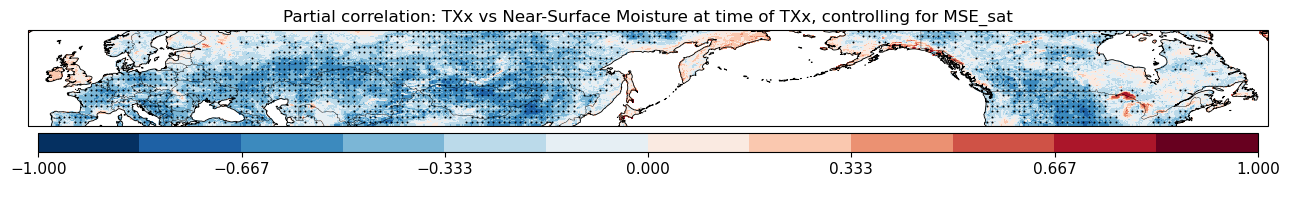

[SAVED] realization 0016
[SAVED] realization 0039
[SAVED] realization 0059
[SAVED] realization 0078
[SAVED] realization 0096
[SAVED] realization 0116
[SAVED] realization 0135
[SAVED] realization 0155
[SAVED] realization 0174
[SAVED] realization 0194
[SAVED] realization 0211
[SAVED] realization 0230
[SAVED] realization 0252
[SAVED] realization 0271
[SAVED] realization 0291
[SAVED] realization 0312
[SAVED] realization 0336
[SAVED] realization 0358
[SAVED] realization 0380
[SAVED] realization 0401
[SAVED] realization 0421
[SAVED] realization 0441
[SAVED] realization 0462
[SAVED] realization 0482
[SAVED] realization 0503
[SAVED] realization 0522
[SAVED] realization 0543
[SAVED] realization 0563
[SAVED] realization 0584
[SAVED] realization 0604
[SAVED] realization 0624
[SAVED] realization 0645
[SAVED] realization 0666
[SAVED] realization 0686
[SAVED] realization 0707
[SAVED] realization 0727
[SAVED] realization 0749
[SAVED] realization 0770
[SAVED] realization 0790
[SAVED] realization 0811


In [18]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import regionmask

# -----------------------
# Paths
# -----------------------
path_txx = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"

path_null = (
    "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/"
    "random_q_null_partial_correlations_mse/"
    "partial_corr_txx_random_q_all_realizations.nc"
)

# -----------------------
# Load dataset
# -----------------------
ds = xr.open_dataset(path_txx)

lat_min, lat_max = 40.0, 65.0

def sel_lat_band(ds_in, lat_min, lat_max, lat_name="lat"):
    lat = ds_in[lat_name]
    if lat[0] > lat[-1]:
        return ds_in.sel({lat_name: slice(lat_max, lat_min)})
    else:
        return ds_in.sel({lat_name: slice(lat_min, lat_max)})

ds_band = sel_lat_band(ds, lat_min, lat_max).sortby("lon")

# -----------------------
# Variables
# -----------------------
txx = ds_band["txx"]
q   = ds_band["q_at_tasmax"]
mse = ds_band["mse_sat"]          # control variable

txx, q, mse = xr.align(txx, q, mse, join="inner")

# -----------------------
# Require at least N valid years per grid cell
# -----------------------
min_n = 20

valid = np.isfinite(txx) & np.isfinite(q) & np.isfinite(mse)
nvalid = valid.sum("year")

txx = txx.where(valid).where(nvalid >= min_n)
q   = q.where(valid).where(nvalid >= min_n)
mse = mse.where(valid).where(nvalid >= min_n)

# -----------------------
# Observed partial correlation
# TXx vs q_at_tasmax, controlling for mse_sat
# -----------------------
r_txx_q   = xr.corr(txx, q, dim="year")
r_txx_mse = xr.corr(txx, mse, dim="year")
r_q_mse   = xr.corr(q, mse, dim="year")

r = (
    (r_txx_q - r_txx_mse * r_q_mse)
    / np.sqrt((1 - r_txx_mse**2) * (1 - r_q_mse**2))
)

r = r.where(np.isfinite(r))
print("done with partials")

# -----------------------
# Land-only mask
# -----------------------
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110

land_mask = land.mask(
    ds_band["lon"],
    ds_band["lat"],
    wrap_lon=True
) == 0

r_land = r.where(land_mask)

# -----------------------
# Load null partial correlations
# -----------------------
ds_null = xr.open_dataset(path_null)

# Handle ncecat-style output
if "realization" in ds_null.dims and ds_null.sizes["realization"] == 1:
    ds_null = ds_null.isel(realization=0, drop=True)

if "record" in ds_null.dims:
    ds_null = ds_null.rename({"record": "realization"})

ds_null = ds_null.assign_coords(
    realization=np.arange(ds_null.sizes["realization"])
)

# Adjust this if your variable name differs
if "r_partial_txx_random_q_control_mse" in ds_null:
    r_null = ds_null["r_partial_txx_random_q_control_mse"]
elif "r_partial_txx_random_q_control_mse_sat" in ds_null:
    r_null = ds_null["r_partial_txx_random_q_control_mse_sat"]
else:
    print(ds_null)
    raise KeyError("Could not find partial-correlation variable for mse_sat control.")

r_null_band = sel_lat_band(r_null, lat_min, lat_max).sortby("lon")

# Align observed and null
r_obs, r_null_band = xr.align(r_land, r_null_band, join="inner")

# -----------------------
# Significance
# -----------------------
p_value = (
    (np.abs(r_null_band) >= np.abs(r_obs)).sum("realization") + 1
) / (r_null_band.sizes["realization"] + 1)

land_mask_obs, p_value, r_obs = xr.align(
    land_mask,
    p_value,
    r_obs,
    join="inner"
)

sig_mask = (
    (p_value < 0.05)
    & (r_obs < 0)
    & land_mask_obs
    & np.isfinite(r_obs)
).fillna(False)

# -----------------------
# Plot partial correlation map
# -----------------------
proj = ccrs.PlateCarree(central_longitude=135)
data_crs = ccrs.PlateCarree()

fig = plt.figure(figsize=(16, 4))
ax = plt.axes(projection=proj)

ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, alpha=0.10)

lonL, lonR = -15, 310
ax.set_extent([lonL, lonR, lat_min, lat_max], crs=data_crs)

im = r_obs.plot(
    ax=ax,
    transform=data_crs,
    x="lon",
    y="lat",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    levels=13,
    add_colorbar=False
)

# -----------------------
# Add stippling for significant land grid cells
# -----------------------
step = 5

sig_coarse = sig_mask.isel(
    lat=slice(None, None, step),
    lon=slice(None, None, step)
).fillna(False)

sig_points = sig_coarse.stack(points=("lat", "lon"))
sig_points = sig_points.where(sig_points, drop=True)

ax.scatter(
    sig_points["lon"].values,
    sig_points["lat"].values,
    s=2,
    c="black",
    marker="o",
    transform=data_crs,
    linewidths=0,
    zorder=5
)

ax.set_title(
    "Partial correlation: TXx vs Near-Surface Moisture at time of TXx, controlling for MSE_sat"
)

cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    pad=0.025,
    fraction=0.06,
    aspect=66
)

cbar.set_label(" ", fontsize=12)
cbar.ax.tick_params(labelsize=11)

plt.savefig(
    "q_at_tasmax_vs_TXX_partial_correlation_control_mse_sat_significance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

ds.close()
ds_null.close()
